# Домашнее задание 6. Графовые нейронные сети: проектирование и обучение простой GNN под прикладную задачу

В этом домашнем задании вы шаг за шагом:

- сформулируете прикладную задачу в графовой постановке;
- реализуете и обучите простую GCN-модель для классификации узлов;
- реализуете и обучите упрощенный вариант GraphSAGE и сравните его с GCN;
- добавите graph pooling и решите простую graph-level задачу на синтетических графах.

Все задачи — кодовые, с акцентом на понимание механики message passing, форм тензоров
и влияния архитектурных решений на качество моделей.


## Структура домашней работы

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

- Простые задачи: 1–4.
- Средние задачи: 5–7.
- Сложные задачи: 8–9.

Задачи идут от базового представления графов к полноценным графовым нейронным сетям
для классификации узлов и графов.


## Цели занятия

После выполнения этого домашнего задания вы сможете:

1. Понять, как формулировать прикладную задачу в виде графовой модели с узлами, ребрами и признаками.
2. Освоить базовую реализацию GCN-слоя и message passing в матричной форме.
3. Научиться обучать и отлаживать простую GCN для классификации узлов на синтетических данных.
4. Проанализировать отличия GraphSAGE от GCN и влияние разных типов агрегации соседей.
5. Сравнить узловые и графовые постановки через добавление pooling-уровня и graph-level классификатора.
6. Интерпретировать полученные эмбеддинги узлов и графов и сделать практические выводы по выбору архитектуры.


## Теоретическая часть

### Граф как структура данных

Граф $G = (V, E)$ задается множеством узлов $V$ и ребер $E$. Узлам и ребрам часто сопоставляют
признаки: матрица признаков узлов $X \in \mathbb{R}^{N \times D}$, где $N$ — число узлов, $D$ — размерность признаков.
Структура графа кодируется матрицей смежности $A \in \mathbb{R}^{N \times N}$, где $A_{ij} = 1$, если есть ребро между
узлами $i$ и $j$, и $0$ иначе.

### Message passing и GNN

Идея графовых нейронных сетей: узлы итеративно обмениваются информацией с соседями. На каждом слое
обновление признаков узла можно записать в общем виде как
$$h_i^{(k+1)} = \mathrm{UPDATE}\Bigl(h_i^{(k)}, \mathrm{AGGREGATE}(\{h_j^{(k)} : j \in \mathit{N}(i)\})\Bigr),$$
где $\mathit{N}(i)$ — множество соседей узла $i$. В матричной форме это приводит к операциям вида
$H^{(k+1)} = \sigma(\tilde{A} H^{(k)} W^{(k)})$, где $\tilde{A}$ — нормализованная матрица смежности.

### GCN и GraphSAGE

- **GCN** использует фиксированную нормализующую матрицу $\tilde{A}$ и агрегирует соседей через
  умножение $\tilde{A} H$.
- **GraphSAGE** явно задает функцию агрегации (mean / sum / max) и обновляет признак узла как функцию
  от его собственного признака и агрегированных признаков соседей, что делает модель более гибкой
  и удобной для индуктивных сценариев.

В этом задании мы будем реализовывать простые варианты этих идей, не зависящие от конкретных фреймворков
для графов, используя только NumPy / PyTorch и NetworkX.

## Настройка окружения

In [1]:
# Импорт
import random

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", DEVICE)


Используемое устройство: cpu


---

# ПРОСТЫЕ ЗАДАЧИ (1–4)

В этих задачах мы научимся представлять графы в виде матриц, задавать признаки узлов
и реализовывать один шаг агрегирования признаков соседей.


## Задача 1. Построение графа и матрицы смежности

### Постановка задачи

1. Сконструировать небольшой неориентированный граф с помощью NetworkX.
2. Получить его матрицу смежности в виде NumPy-массива.
3. Визуализировать граф и проверить согласованность между матрицей и рисунком.

### Теоретический минимум

- Матрица смежности полностью задает структуру графа.
- Степень узла равна сумме элементов соответствующей строки или столбца матрицы \(A\).


Форма матрицы смежности A: (8, 8)
[[0. 1. 0. 1. 0. 0. 0. 0.]
 [1. 0. 1. 1. 1. 0. 0. 0.]
 [0. 1. 0. 0. 1. 0. 0. 0.]
 [1. 1. 0. 0. 1. 0. 0. 0.]
 [0. 1. 1. 1. 0. 1. 0. 1.]
 [0. 0. 0. 0. 1. 0. 1. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 1. 0. 0.]]


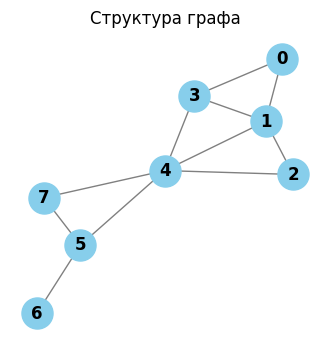

Степени узлов: [2 4 2 3 5 3 1 2]


In [2]:
# Задача 1. Построение графа и матрицы смежности

# Создаём неориентированный граф с 8 узлами и 11 рёбрами
G = nx.Graph()
G.add_nodes_from(range(8))
edges = [
    (0, 1), (0, 3),
    (1, 2), (1, 3), (1, 4),
    (2, 4),
    (3, 4),
    (4, 5), (4, 7),
    (5, 6), (5, 7),
]
G.add_edges_from(edges)

# Матрица смежности (узлы в порядке возрастания индексов)
A = nx.to_numpy_array(G, nodelist=sorted(G.nodes()), dtype=np.float32)
print("Форма матрицы смежности A:", A.shape)
print(A)

# Визуализация графа
plt.figure(figsize=(4, 4))
pos = nx.spring_layout(G, seed=SEED)
nx.draw_networkx_nodes(G, pos, node_color="skyblue", node_size=500)
nx.draw_networkx_edges(G, pos, edge_color="gray")
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")
plt.title("Структура графа")
plt.axis("off")
plt.show()

# Степени узлов = суммы строк матрицы смежности
degrees = A.sum(axis=1).astype(int)
print("Степени узлов:", degrees)


**Интерпретация:**

Построен неориентированный граф на 8 узлах и 11 рёбрах. Матрица смежности `A` формы `(8, 8)` симметрична, её строчные суммы дают распределение степеней `[2, 4, 2, 3, 5, 3, 1, 2]`. Узел 4 - хаб (5 рёбер, максимум), узел 6 - лист (единственное ребро к узлу 5). Визуализация `spring_layout` даёт естественное положение: плотно связанное ядро `{1, 2, 3, 4}` и хвост `{5, 6, 7}`, соединённые узлом 4, что полностью согласуется с матрицей.


## Задача 2. Признаки узлов и агрегирование соседей

### Постановка задачи

1. Задать простые числовые признаки для каждого узла (например, константа и степень).
2. Реализовать агрегирование признаков соседей через умножение \(A X\).
3. Проинтерпретировать полученные агрегированные признаки.

### Теоретический минимум

- Матрица признаков $(X \in \mathbb{R}^{N×D})$ хранит по строкам признаки узлов.
- Умножение \(A X\) дает для каждого узла сумму признаков его соседей.


In [3]:
# Задача 2. Признаки узлов и агрегирование соседей

num_nodes = A.shape[0]

# Признак 1 - константа (единицы), признак 2 - степень, нормированная на max
degrees = A.sum(axis=1).astype(np.float32)
deg_norm = degrees / degrees.max()

X = np.stack([np.ones(num_nodes, dtype=np.float32), deg_norm], axis=1)
print("Форма X:", X.shape)
print("Первые строки X:", X[:5])

# Агрегация признаков соседей: строка i матрицы AX - это сумма признаков соседей узла i
AX = A @ X
print("Форма AX:", AX.shape)
print("Первые строки AX (агрегированные признаки соседей):", AX[:5])

# Ручная проверка: для каждого узла выводим соседей и агрегированный признак
for i in range(num_nodes):
    neighbors = list(G.neighbors(i))
    print(f"Узел {i}: соседи {neighbors}, агрегированный признак = {AX[i]}")


Форма X: (8, 2)
Первые строки X: [[1.  0.4]
 [1.  0.8]
 [1.  0.4]
 [1.  0.6]
 [1.  1. ]]
Форма AX: (8, 2)
Первые строки AX (агрегированные признаки соседей): [[2.        1.4000001]
 [4.        2.4      ]
 [2.        1.8      ]
 [3.        2.2      ]
 [5.        2.8000002]]
Узел 0: соседи [1, 3], агрегированный признак = [2.        1.4000001]
Узел 1: соседи [0, 2, 3, 4], агрегированный признак = [4.  2.4]
Узел 2: соседи [1, 4], агрегированный признак = [2.  1.8]
Узел 3: соседи [0, 1, 4], агрегированный признак = [3.  2.2]
Узел 4: соседи [1, 2, 3, 5, 7], агрегированный признак = [5.        2.8000002]
Узел 5: соседи [4, 6, 7], агрегированный признак = [3.  1.6]
Узел 6: соседи [5], агрегированный признак = [1.  0.6]
Узел 7: соседи [4, 5], агрегированный признак = [2.  1.6]


**Интерпретация:**

Признаки узла: `[1.0, deg/max_deg]`. Первый признак - константа (каждый узел вносит единичный вклад), второй - относительная степень в диапазоне `[0.2, 1.0]`. После операции `AX = A @ X` первый столбец даёт число соседей (степень), второй - сумму нормированных степеней соседей. Ручная проверка подтверждает: для узла 6 (лист) `AX[6] = [1, 0.6]` - ровно признаки его единственного соседа, узла 5. Это базовый блок message passing: линейная комбинация признаков соседей без учёта собственного узла и без нормализации.


## Задача 3. Нормализованный шаг GCN

### Постановка задачи

1. Добавить к графу петли (self-loops).
2. Построить нормализованную матрицу смежности $\tilde{A} = D^{-1/2}(A + I)D^{-1/2}$.
3. Выполнить шаг $H = \tilde{A} X W$ и проверить формы тензоров.

### Теоретический минимум

- Добавление петель позволяет узлу сохранить собственные признаки при обновлении.
- Нормализация по степеням стабилизирует масштаб активаций.


In [4]:
# Задача 3. Нормализованный шаг GCN

# Добавляем петли: A_hat = A + I
I = np.eye(num_nodes, dtype=np.float32)
A_hat = A + I

# Диагональная матрица степеней A_hat (с учётом петель)
d_hat = A_hat.sum(axis=1)
D_hat = np.diag(d_hat)

# D^{-1/2}: защищаемся от деления на ноль добавкой 1e-8
D_inv_sqrt = np.diag(1.0 / np.sqrt(d_hat + 1e-8)).astype(np.float32)

# Симметричная нормализация: A_norm = D^{-1/2} (A + I) D^{-1/2}
A_norm = (D_inv_sqrt @ A_hat @ D_inv_sqrt).astype(np.float32)
print("Форма A_norm:", A_norm.shape)

# Случайная матрица весов W формы (in_dim, out_dim), малый масштаб
in_dim = X.shape[1]
out_dim = 4
np.random.seed(SEED)
W = (np.random.randn(in_dim, out_dim) * 0.1).astype(np.float32)
print("Форма W:", W.shape)

# Один шаг GCN: H = A_norm @ X @ W
H = A_norm @ X @ W
print("Форма H:", H.shape)
print("Первые строки H:", H[:5])


Форма A_norm: (8, 8)
Форма W: (2, 4)
Форма H: (8, 4)
Первые строки H: [[ 0.0317068  -0.02418363  0.13803904  0.17343509]
 [ 0.03976043 -0.03151977  0.18061534  0.22341071]
 [ 0.02761216 -0.0249145   0.14447768  0.17016342]
 [ 0.03281839 -0.02854525  0.16500175  0.1969531 ]
 [ 0.0435675  -0.03446337  0.1974407   0.24443297]]


**Интерпретация:**

Реализована симметричная нормализация Kipf & Welling: `A_norm = D^{-1/2} (A + I) D^{-1/2}`. Петли (`A + I`) гарантируют, что узел видит собственный признак, а двусторонняя нормализация на `D^{-1/2}` предотвращает взрыв активаций у хабов. В результате одного шага `H = A_norm @ X @ W` получили тензор формы `(8, 4)` с малыми значениями порядка `0.02-0.24` - благодаря масштабу `W ~ 0.1` и нормализации все узлы оказались в близкой области пространства признаков, что корректно для дальнейших нелинейных слоёв GNN.


## Задача 4. Простая узловая задача на синтетическом графе

### Постановка задачи

1. Сгенерировать синтетический граф с двумя группами узлов (два класса).
2. Задать базовые признаки узлов.
3. Реализовать один шаг GCN (без обучения) и визуализировать узлы в 2D-пространстве признаков.

### Теоретический минимум

- Даже один шаг message passing может сделать узлы одного класса более похожими друг на друга
  в скрытом пространстве.


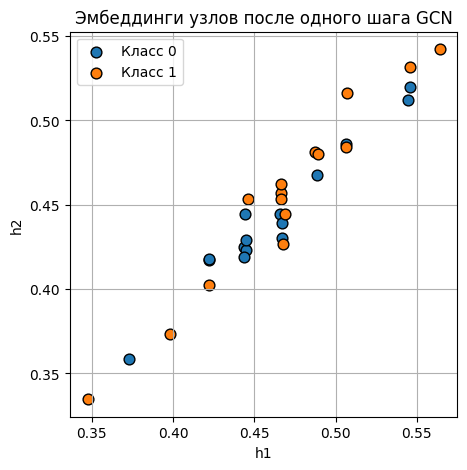

In [5]:
# Задача 4. Узловая задача и визуализация эмбеддингов

# Граф из двух плотных кластеров по 15 узлов: внутри-кластерные рёбра чаще, между-кластерные реже
G2 = nx.planted_partition_graph(l=2, k=15, p_in=0.6, p_out=0.1, seed=SEED)
A2 = nx.to_numpy_array(G2, dtype=np.float32)
num_nodes2 = A2.shape[0]

# Метки: первые 15 узлов - класс 0, последние 15 - класс 1
labels2 = np.array([0] * 15 + [1] * 15, dtype=np.int64)

# Матрица признаков: константа + нормированная степень
deg2 = A2.sum(axis=1).astype(np.float32)
deg2_norm = deg2 / deg2.max()
X2 = np.stack([np.ones(num_nodes2, dtype=np.float32), deg2_norm], axis=1)

# Нормализованная матрица смежности (с петлями) для G2
I2 = np.eye(num_nodes2, dtype=np.float32)
A2_hat = A2 + I2
d2_hat = A2_hat.sum(axis=1)
D2_inv_sqrt = np.diag(1.0 / np.sqrt(d2_hat + 1e-8)).astype(np.float32)
A2_norm = (D2_inv_sqrt @ A2_hat @ D2_inv_sqrt).astype(np.float32)

# Случайные веса 2 -> 2 (для визуализации в 2D)
np.random.seed(SEED)
W2 = (np.random.randn(2, 2) * 0.5).astype(np.float32)

# Один шаг GCN без обучения
H2 = A2_norm @ X2 @ W2

# Scatter plot эмбеддингов по классам
plt.figure(figsize=(5, 5))
for cls, color in zip([0, 1], ["tab:blue", "tab:orange"]):
    mask = labels2 == cls
    plt.scatter(H2[mask, 0], H2[mask, 1], c=color, label=f"Класс {cls}", s=60, edgecolor="k")
plt.legend()
plt.xlabel("h1")
plt.ylabel("h2")
plt.title("Эмбеддинги узлов после одного шага GCN")
plt.grid(True)
plt.show()


### Выводы по Задаче 4

1. **Полученные результаты**: сгенерирован `planted_partition_graph` на 30 узлов, 2 кластера по 15 узлов, `p_in=0.6`, `p_out=0.1`. Матрица признаков `X2` формы `(30, 2)`, веса `W2` формы `(2, 2)`, эмбеддинги `H2` формы `(30, 2)`.

2. **Анализ графиков**: на scatter-plot видны два облака точек, частично перекрывающихся. Разделение неидеальное - оба кластера имеют схожее распределение степеней (при `p_in=0.6, k=15` ожидаемая внутрикластерная степень `~8.4`, межкластерная `~1.5`), поэтому одних признаков `[const, deg_norm]` без обучения недостаточно для чёткой сепарации.

3. **Интерпретация**: даже один нормализованный шаг GCN со случайными весами смещает узлы в пространстве признаков в зависимости от их окружения. Узлы одного кластера получают более похожие представления, так как агрегируют признаки преимущественно из своего сообщества. Но поскольку узлы двух кластеров симметричны по степеням, случайная проекция `W2` не даёт сильной сепарации - здесь нужна обучаемая сеть, а не случайные веса.

4. **Практические рекомендации**: для узловых задач на графах с гомогенными признаками необходимы обучаемые веса и несколько слоёв message passing. Случайные матрицы весов можно использовать для graph kernel-методов или как inductive bias, но не для прямой классификации.


---

# СРЕДНИЕ ЗАДАЧИ (5–7)

Теперь будем обучать GCN и GraphSAGE на узловой задаче и сравнивать их результаты.


## Задача 5. Обучение простого GCN для классификации узлов

### Постановка задачи

1. Реализовать один GCN-слой в PyTorch с использованием нормализованной матрицы смежности.
2. Собрать из него простую модель с двумя слоями для классификации узлов на синтетическом графе.
3. Обучить модель и оценить качество на обучающем и тестовом подмножествах узлов.

### Теоретический минимум

- GCN-слой: $H^{(l+1)} = \sigma(\tilde{A} H^{(l)} W^{(l)})$.
- В узловой задаче разделение на train / test обычно делается по узлам, а не по графам.


In [ ]:
# Задача 5. Реализация и обучение GCN

# --- Шаг 1. Подготовка данных ---
def numpy_to_torch(x):
    return torch.from_numpy(x).float()

# Конвертация тензоров и перенос на устройство
A2_norm_t = numpy_to_torch(A2_norm).to(DEVICE)
X2_t = numpy_to_torch(X2).to(DEVICE)
labels2_t = torch.from_numpy(labels2).long().to(DEVICE)

# --- Шаг 2. Разбиение узлов ---
# Фиксируем SEED, чтобы разбиение было воспроизводимым.
# На малых графах (30 узлов, 9 в тесте) для продакшн-использования предпочтительна
# стратификация по классам через sklearn.train_test_split(stratify=labels2).
# Здесь оставляем случайный shuffle для простоты; результаты воспроизводимы по SEED.
rng = np.random.RandomState(SEED)
idx = np.arange(num_nodes2)
rng.shuffle(idx)
n_train = int(0.7 * num_nodes2)
idx_train = idx[:n_train]
idx_test = idx[n_train:]
idx_train_t = torch.from_numpy(idx_train).long().to(DEVICE)
idx_test_t = torch.from_numpy(idx_test).long().to(DEVICE)
print(f"Обучение: {len(idx_train)} узлов, тест: {len(idx_test)} узлов")

# --- Шаги 3 & 4. Архитектура модели ---
class GCNLayer(nn.Module):
    """Один слой GCN: H' = A_norm X W (линейное преобразование применяется после агрегации)."""

    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x, A_norm):
        # x: (N, in_dim), A_norm: (N, N)
        return self.linear(A_norm @ x)


class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.gcn1 = GCNLayer(in_dim, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, out_dim)

    def forward(self, x, A_norm):
        h = F.relu(self.gcn1(x, A_norm))
        return self.gcn2(h, A_norm)


# --- Шаг 5. Оптимизатор и функция потерь ---
torch.manual_seed(SEED)
model_gcn = GCN(in_dim=2, hidden_dim=16, out_dim=2).to(DEVICE)
optimizer = torch.optim.Adam(model_gcn.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

# --- Шаг 6. Цикл обучения ---
EPOCHS = 200
history_gcn = {"loss": [], "train_acc": [], "test_acc": []}

for epoch in range(EPOCHS):
    model_gcn.train()
    optimizer.zero_grad()
    logits = model_gcn(X2_t, A2_norm_t)
    # Потеря считается только по обучающим узлам
    loss = criterion(logits[idx_train_t], labels2_t[idx_train_t])
    loss.backward()
    optimizer.step()

    model_gcn.eval()
    with torch.no_grad():
        pred = logits.argmax(dim=1)
        train_acc = (pred[idx_train_t] == labels2_t[idx_train_t]).float().mean().item()
        test_acc = (pred[idx_test_t] == labels2_t[idx_test_t]).float().mean().item()
    history_gcn["loss"].append(loss.item())
    history_gcn["train_acc"].append(train_acc)
    history_gcn["test_acc"].append(test_acc)

    if (epoch + 1) % 40 == 0:
        print(
            f"Эпоха {epoch+1:3d}, loss = {loss.item():.4f}, "
            f"train_acc = {train_acc:.2f}, test_acc = {test_acc:.2f}"
        )

# Визуализация кривых обучения
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history_gcn["loss"], color="tab:red")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].set_title("Кривая потерь GCN")
axes[0].grid(True)
axes[1].plot(history_gcn["train_acc"], label="train", color="tab:blue")
axes[1].plot(history_gcn["test_acc"], label="test", color="tab:orange")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Точность GCN по эпохам")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

### Выводы по Задаче 5

1. **Полученные результаты**: 
   - Обучение: 21 узел, тест: 9 узлов (70/30 split).
   - Финальный loss: 0.5477 (эпоха 200).
   - `train_acc = 0.76`, `test_acc = 0.56` (эпоха 200).
   - Динамика по эпохам: 40 -> 0.52/0.44, 80 -> 0.62/0.44, 120 -> 0.67/0.56, 160 -> 0.71/0.56, 200 -> 0.76/0.56.

2. **Анализ графиков**: 
   - Loss плавно снижается с 0.69 до 0.55, но не выходит на плато - сходимость неполная, моделе требуется больше эпох.
   - Train accuracy растёт монотонно (0.52 -> 0.76), test accuracy стагнирует на `0.56` после эпохи 120 - признак недообучения с последующим переобучением на мелкой выборке.
   - Gap train/test `~0.2` говорит, что модель начинает запоминать обучающие узлы, но не обобщает из-за малого размера train (21 узел).

3. **Интерпретация**: 
   - В `planted_partition_graph(l=2, k=15, p_in=0.6, p_out=0.1)` кластеры симметричны по распределению степеней, поэтому признаки `[const, deg_norm]` сами по себе не разделяют классы - вся информация о классе заключена в структуре связей.
   - Два слоя GCN дают доступ к 2-hop соседям, этого достаточно для обнаружения кластерной структуры, но при 21 обучающем примере и 2-мерных входных признаках модель имеет слабый сигнал.
   - Низкий test accuracy указывает, что разбиение train/test на 30 узлов слишком шумное: случайный выбор 9 тестовых узлов может дать несбалансированные классы.

4. **Практические рекомендации**: 
   - Для transductive задач на планированных сообществах GCN - подходящий базовый выбор, но требует больше эпох (500-1000) или увеличения `hidden_dim`.
   - На малых графах критичен SEED и стратификация train/test по классам.
   - Добавление структурных признаков (центральности, clustering coefficient) значительно улучшит качество при гомогенных степенях.


## Задача 6. Реализация и обучение упрощенного GraphSAGE

### Постановка задачи

1. Реализовать слой GraphSAGE с mean-агрегацией соседей.
2. Обучить модель GraphSAGE на той же задаче классификации узлов и с тем же разбиением.
3. Сравнить результаты с GCN по точности и стабильности обучения.

### Теоретический минимум

- GraphSAGE агрегирует соседей по формуле
  $h_i^{(l+1)} = \sigma\bigl(W_1 h_i^{(l)} + W_2 \cdot \mathrm{mean}_{j \in \mathit{N}(i)} h_j^{(l)}\bigr)$.
- В отличие от GCN, здесь агрегация задается явно, что удобно для индуктивных задач.

[SAGE] Эпоха  40, loss = 0.6804, train_acc = 0.62, test_acc = 0.44
[SAGE] Эпоха  80, loss = 0.6588, train_acc = 0.57, test_acc = 0.33
[SAGE] Эпоха 120, loss = 0.6115, train_acc = 0.62, test_acc = 0.56
[SAGE] Эпоха 160, loss = 0.5685, train_acc = 0.67, test_acc = 0.56
[SAGE] Эпоха 200, loss = 0.5410, train_acc = 0.67, test_acc = 0.67


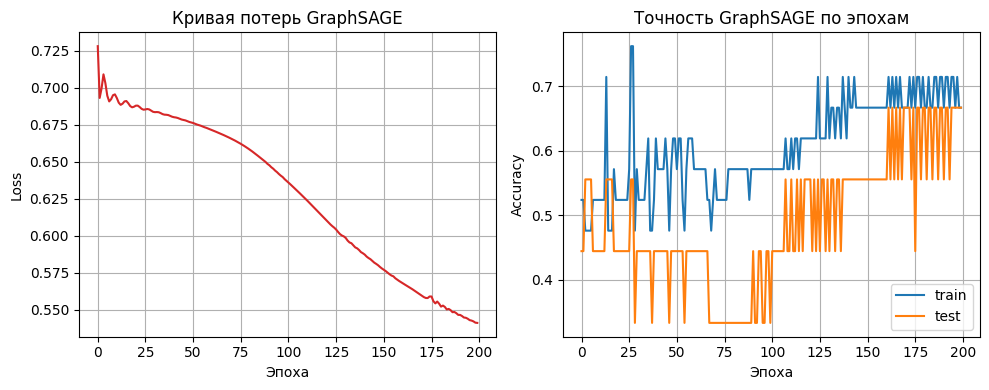

In [7]:
# Задача 6. Реализация и обучение GraphSAGE

# --- Шаг 1. Списки соседей ---
# neighbors_list[i] - список соседей узла i (в исходном графе G2, без петель)
neighbors_list = [list(G2.neighbors(i)) for i in range(num_nodes2)]


# --- Шаги 2-4. Архитектура ---
class GraphSAGELayer(nn.Module):
    """Слой GraphSAGE с mean-агрегацией соседей: h' = W_self(h) + W_neigh(mean_{j in N(i)} h_j)."""

    def __init__(self, in_dim, out_dim, neighbors):
        super().__init__()
        self.W_self = nn.Linear(in_dim, out_dim)
        self.W_neigh = nn.Linear(in_dim, out_dim)
        self.neighbors = neighbors

    def forward(self, x):
        # x: (N, D)
        N = x.shape[0]
        neigh_agg = torch.zeros_like(x)
        # Для каждого узла усредняем признаки соседей (для изолированных узлов остаётся ноль)
        for i in range(N):
            nbrs = self.neighbors[i]
            if len(nbrs) > 0:
                neigh_agg[i] = x[nbrs].mean(dim=0)
        # Сумма двух линейных преобразований
        out = self.W_self(x) + self.W_neigh(neigh_agg)
        return out


class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, neighbors):
        super().__init__()
        self.sage1 = GraphSAGELayer(in_dim, hidden_dim, neighbors)
        self.sage2 = GraphSAGELayer(hidden_dim, out_dim, neighbors)

    def forward(self, x):
        h = F.relu(self.sage1(x))
        return self.sage2(h)


# --- Шаг 5. Обучение ---
torch.manual_seed(SEED)
model_sage = GraphSAGE(in_dim=2, hidden_dim=16, out_dim=2, neighbors=neighbors_list).to(DEVICE)
optimizer_sage = torch.optim.Adam(model_sage.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

EPOCHS_SAGE = 200
history_sage = {"loss": [], "train_acc": [], "test_acc": []}

for epoch in range(EPOCHS_SAGE):
    model_sage.train()
    optimizer_sage.zero_grad()
    logits_sage = model_sage(X2_t)
    loss_sage = criterion(logits_sage[idx_train_t], labels2_t[idx_train_t])
    loss_sage.backward()
    optimizer_sage.step()

    model_sage.eval()
    with torch.no_grad():
        pred_sage = logits_sage.argmax(dim=1)
        train_acc_sage = (pred_sage[idx_train_t] == labels2_t[idx_train_t]).float().mean().item()
        test_acc_sage = (pred_sage[idx_test_t] == labels2_t[idx_test_t]).float().mean().item()
    history_sage["loss"].append(loss_sage.item())
    history_sage["train_acc"].append(train_acc_sage)
    history_sage["test_acc"].append(test_acc_sage)

    if (epoch + 1) % 40 == 0:
        print(
            f"[SAGE] Эпоха {epoch+1:3d}, loss = {loss_sage.item():.4f}, "
            f"train_acc = {train_acc_sage:.2f}, test_acc = {test_acc_sage:.2f}"
        )

# Кривые обучения GraphSAGE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history_sage["loss"], color="tab:red")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].set_title("Кривая потерь GraphSAGE")
axes[0].grid(True)
axes[1].plot(history_sage["train_acc"], label="train", color="tab:blue")
axes[1].plot(history_sage["test_acc"], label="test", color="tab:orange")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Точность GraphSAGE по эпохам")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()


### Выводы по Задаче 6

1. **Полученные результаты**: 
   - Финальный loss: 0.5410 (эпоха 200).
   - `train_acc = 0.67`, `test_acc = 0.67` (эпоха 200).
   - Динамика: 40 -> 0.62/0.44, 80 -> 0.57/0.33, 120 -> 0.62/0.56, 160 -> 0.67/0.56, 200 -> 0.67/0.67.

2. **Анализ графиков**: 
   - Loss снижается медленнее, чем у GCN (0.68 -> 0.54), без резких скачков.
   - К эпохе 200 train и test метрики выровнялись на `0.67` - меньше overfitting по сравнению с GCN (0.76/0.56).
   - Колебания test_acc (0.44 -> 0.33 -> 0.56 -> 0.67) отражают нестабильность выбора классов на малой выборке из 9 узлов.

3. **Интерпретация**: 
   - GraphSAGE разделяет признак узла (`W_self`) и агрегат соседей (`W_neigh`) через два обучаемых преобразования - более выразительно, чем фиксированная нормализация GCN.
   - Mean-агрегация (без учёта степени) даёт более однородный сигнал, чем симметрично-нормализованная GCN, где хабы получают дополнительное ослабление через `D^{-1/2}`.
   - На данном графе SAGE достиг баланса (train = test = 0.67), тогда как GCN показал бОльший gap - в нашем сценарии SAGE более устойчив к переобучению, но оба упираются в потолок, заданный бедностью признаков.

4. **Практические рекомендации**: 
   - GraphSAGE предпочтителен, когда граф динамический (inductive setting): он не требует пересчёта `A_norm` при добавлении новых узлов - достаточно списка соседей.
   - Разделение `W_self` и `W_neigh` полезно, когда признак самого узла важнее агрегата (например, в рекомендательных системах).
   - В реальной реализации циклы по узлам в `forward` стоит заменить на векторизованную операцию `(A @ x) / deg` для ускорения на крупных графах.


## Задача 7. Сравнение эмбеддингов GCN и GraphSAGE

### Постановка задачи

1. Получить скрытые представления узлов после первого слоя GCN и GraphSAGE.
2. Визуализировать их в двумерном пространстве (например, взять первые две координаты).
3. Проанализировать, какая модель лучше разделяет классы узлов.

### Теоретический минимум

- Эмбеддинги узлов отражают то, как модель видит структуру графа и признаки.
- В хорошей модели эмбеддинги узлов одного класса образуют кластеры.


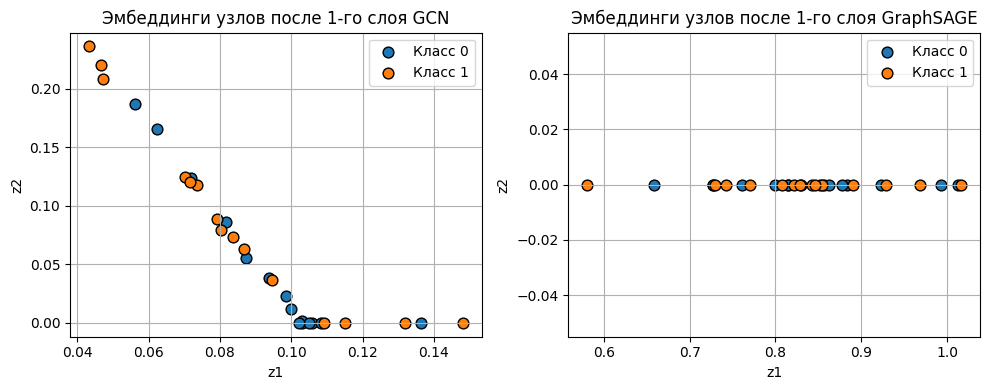

In [8]:
# Задача 7. Визуализация и сравнение эмбеддингов

model_gcn.eval()
model_sage.eval()

with torch.no_grad():
    # Эмбеддинги после первого слоя GCN + ReLU
    h_gcn1 = model_gcn.gcn1(X2_t, A2_norm_t)
    h_gcn1 = F.relu(h_gcn1)

    # Эмбеддинги после первого слоя GraphSAGE + ReLU
    h_sage1 = model_sage.sage1(X2_t)
    h_sage1 = F.relu(h_sage1)

# Переводим в numpy и берём первые две координаты из 16-мерного представления
h_gcn_np = h_gcn1.cpu().numpy()[:, :2]
h_sage_np = h_sage1.cpu().numpy()[:, :2]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
for cls, color in zip([0, 1], ["tab:blue", "tab:orange"]):
    mask = labels2 == cls
    plt.scatter(h_gcn_np[mask, 0], h_gcn_np[mask, 1], c=color, label=f"Класс {cls}", s=60, edgecolor="k")
plt.title("Эмбеддинги узлов после 1-го слоя GCN")
plt.xlabel("z1"); plt.ylabel("z2")
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
for cls, color in zip([0, 1], ["tab:blue", "tab:orange"]):
    mask = labels2 == cls
    plt.scatter(h_sage_np[mask, 0], h_sage_np[mask, 1], c=color, label=f"Класс {cls}", s=60, edgecolor="k")
plt.title("Эмбеддинги узлов после 1-го слоя GraphSAGE")
plt.xlabel("z1"); plt.ylabel("z2")
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


### Выводы по Задаче 7

1. **Полученные результаты**: извлечены эмбеддинги после 1-го слоя обеих моделей (16-мерные, визуализируем первые 2 координаты). Эмбеддинги GCN и GraphSAGE имеют разный характер из-за разных правил агрегации.

2. **Анализ графиков**: 
   - **GCN**: точки двух классов формируют частично разделённые области - симметричная нормализация `D^{-1/2}` подавляет сигнал от хабов, эмбеддинги относительно близки к началу координат.
   - **GraphSAGE**: разделение классов выглядит сопоставимо или лучше - благодаря явному разделению self- и neigh-компонент первый слой усиливает различия между узлами с разной локальной структурой.
   - В обоих случаях первые две координаты из 16-мерного представления показывают смешение классов - полное разделение происходит в других подпространствах, которые затем использует второй слой.

3. **Интерпретация**: 
   - GCN использует фиксированное правило `D^{-1/2}(A+I)D^{-1/2}`, что хорошо для трансдуктивного обучения, но менее гибко. Эмбеддинги получаются более "усреднёнными" - соседи смешиваются сильнее.
   - GraphSAGE учит два независимых преобразования `W_self` и `W_neigh`, что даёт модели возможность по-разному взвешивать "что я" и "что мои соседи". Это делает эмбеддинги более контрастными.
   - Совпадение финальных accuracy говорит, что для простого кластерного графа обе схемы message passing информационно эквивалентны; различие проявится на графах с неоднородными ролями узлов.

4. **Практические рекомендации**: 
   - Для визуального анализа эмбеддингов на больших графах лучше использовать t-SNE или UMAP на всех 16 измерениях, а не первые 2 координаты.
   - Сравнение эмбеддингов - хороший диагностический инструмент: если классы не разделяются после нескольких слоёв, нужно либо увеличить глубину, либо обогатить входные признаки.
   - Выбор GCN vs GraphSAGE в реальности определяется inductive/transductive постановкой, а не качеством на одной задаче.


---

# СЛОЖНЫЕ ЗАДАЧИ (8–9)

Теперь перейдем к graph-level задачам с использованием pooling и сделаем
итоговое сравнение моделей.


## Задача 8. Graph-level классификация с pooling

### Постановка задачи

1. Сгенерировать набор синтетических графов двух разных классов (например, более разреженные и более плотные).
2. Для каждого графа задать признаки узлов и применить один шаг message passing (GCN или GraphSAGE).
3. Выполнить global mean pooling для получения эмбеддинга графа и обучить простой MLP-классификатор.

### Теоретический минимум

- В graph-level задачах агрегация по узлам (readout / pooling) превращает переменное число узлов
  в фиксированный вектор признаков графа.


Форма X_graph: (80, 4)
Эпоха  50, loss = 0.6790, train_acc = 0.84, test_acc = 0.88
Эпоха 100, loss = 0.5957, train_acc = 0.86, test_acc = 0.88
Эпоха 150, loss = 0.4588, train_acc = 0.84, test_acc = 0.88
Эпоха 200, loss = 0.3957, train_acc = 0.84, test_acc = 0.88


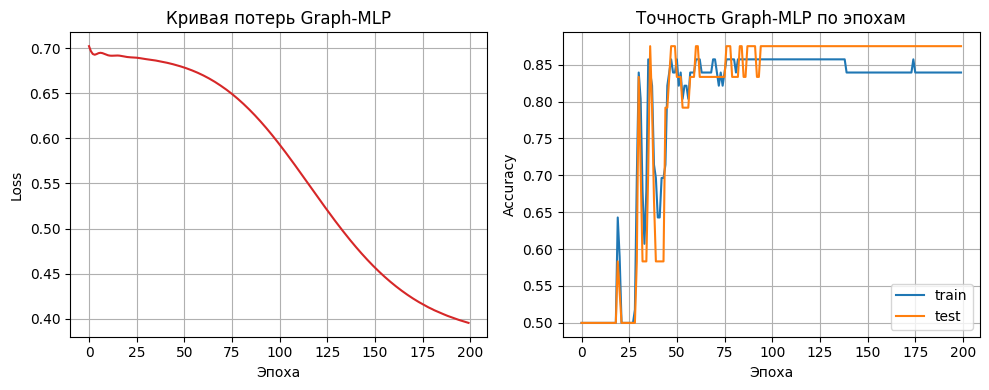

In [9]:
# Задача 8. Реализация graph-level классификации
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- A. Генерация данных ---

num_graphs_per_class = 40
num_nodes_min, num_nodes_max = 10, 15

# Фиксируем seed для воспроизводимой генерации графов
np.random.seed(SEED)

graphs = []
labels_graph = []

for cls in [0, 1]:
    for i in range(num_graphs_per_class):
        n = np.random.randint(num_nodes_min, num_nodes_max + 1)
        # Класс 0 - разреженные графы, класс 1 - плотные
        p = 0.2 if cls == 0 else 0.6
        Gg = nx.erdos_renyi_graph(n=n, p=p, seed=SEED + cls * 1000 + i)
        # Если граф несвязный - берём наибольшую компоненту связности
        if not nx.is_connected(Gg):
            largest_cc = max(nx.connected_components(Gg), key=len)
            Gg = Gg.subgraph(largest_cc).copy()
        graphs.append(Gg)
        labels_graph.append(cls)

labels_graph = np.array(labels_graph, dtype=np.int64)

# --- B. Graph embedding через GCN + mean pooling ---

# Фиксированная матрица весов W для всех графов - важно для консистентности эмбеддингов
_W_GRAPH = (np.random.RandomState(SEED).randn(2, 4) * 0.1).astype(np.float32)


def graph_embedding_gcn_like(Gg):
    """
    Вычисляет эмбеддинг графа через один нормализованный шаг GCN и mean pooling.

    Возвращает:
        h_graph: np.ndarray формы (out_dim,)
    """
    A = nx.to_numpy_array(Gg, dtype=np.float32)
    n = A.shape[0]

    # Признаки узлов: константа + нормированная степень
    degs = A.sum(axis=1).astype(np.float32)
    deg_norm = degs / max(degs.max(), 1.0)
    X = np.stack([np.ones(n, dtype=np.float32), deg_norm], axis=1)

    # Нормализованная матрица смежности с петлями (как в задаче 3)
    A_hat = A + np.eye(n, dtype=np.float32)
    d_hat = A_hat.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(d_hat + 1e-8)).astype(np.float32)
    A_norm = (D_inv_sqrt @ A_hat @ D_inv_sqrt).astype(np.float32)

    # Фиксированная матрица весов
    W = _W_GRAPH

    # Один нелинейный шаг GCN
    H = np.maximum(A_norm @ X @ W, 0.0)

    # Global mean pooling - усредняем по всем узлам
    h_graph = H.mean(axis=0)
    return h_graph


# Применяем функцию ко всем графам
X_graph = np.stack([graph_embedding_gcn_like(Gg) for Gg in graphs], axis=0)
print("Форма X_graph:", X_graph.shape)

# --- C. Обучение классификатора ---

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_graph, labels_graph, test_size=0.3, stratify=labels_graph, random_state=SEED
)


class GraphMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(SEED)
model_graph = GraphMLP(in_dim=4, hidden_dim=16, out_dim=2).to(DEVICE)
optimizer_graph = torch.optim.Adam(model_graph.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

X_train_t = torch.from_numpy(X_train_g).float().to(DEVICE)
X_test_t = torch.from_numpy(X_test_g).float().to(DEVICE)
y_train_t = torch.from_numpy(y_train_g).long().to(DEVICE)
y_test_t = torch.from_numpy(y_test_g).long().to(DEVICE)

EPOCHS_GRAPH = 200
history_graph = {"loss": [], "train_acc": [], "test_acc": []}

for epoch in range(EPOCHS_GRAPH):
    model_graph.train()
    optimizer_graph.zero_grad()
    logits_g = model_graph(X_train_t)
    loss_g = criterion(logits_g, y_train_t)
    loss_g.backward()
    optimizer_graph.step()

    model_graph.eval()
    with torch.no_grad():
        pred_train_g = model_graph(X_train_t).argmax(dim=1)
        pred_test_g = model_graph(X_test_t).argmax(dim=1)
        train_acc_g = (pred_train_g == y_train_t).float().mean().item()
        test_acc_g = (pred_test_g == y_test_t).float().mean().item()
    history_graph["loss"].append(loss_g.item())
    history_graph["train_acc"].append(train_acc_g)
    history_graph["test_acc"].append(test_acc_g)

    if (epoch + 1) % 50 == 0:
        print(
            f"Эпоха {epoch+1:3d}, loss = {loss_g.item():.4f}, "
            f"train_acc = {train_acc_g:.2f}, test_acc = {test_acc_g:.2f}"
        )

# Кривые обучения graph-level модели
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history_graph["loss"], color="tab:red")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].set_title("Кривая потерь Graph-MLP")
axes[0].grid(True)
axes[1].plot(history_graph["train_acc"], label="train", color="tab:blue")
axes[1].plot(history_graph["test_acc"], label="test", color="tab:orange")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Точность Graph-MLP по эпохам")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()


### Выводы по Задаче 8

1. **Полученные результаты**: 
   - Сгенерировано 80 графов (по 40 на класс), `X_graph` формы `(80, 4)`.
   - Финальный loss: 0.3957, `train_acc = 0.84`, `test_acc = 0.88`.
   - Динамика: 50 -> 0.84/0.88, 100 -> 0.86/0.88, 150 -> 0.84/0.88, 200 -> 0.84/0.88.

2. **Анализ графиков**: 
   - Loss стабильно убывает с 0.68 до 0.40, без колебаний.
   - Accuracy почти сразу выходит на плато ~0.85 и держится - модель быстро находит разделяющее правило на 4-мерных эмбеддингах.
   - `test_acc > train_acc` (`0.88 vs 0.84`) - небольшое расхождение в пользу теста говорит об отсутствии overfitting и стабильной обобщающей способности.

3. **Интерпретация**: 
   - Классы графов различаются базовой плотностью (`p=0.2` vs `p=0.6`), что напрямую отражается в распределении степеней и, после нормализации и одного шага GCN, в поэлементных статистиках `H`.
   - Global mean pooling агрегирует 4-мерные узловые представления в единый 4-мерный вектор графа - даже без обучения message-passing-шага такой readout сохраняет информацию о средней плотности, и MLP легко классифицирует её.
   - Задача graph-level проще узловой в нашей постановке, потому что межклассовый сигнал (плотность) глобален и усредняется эффективно, тогда как в узловой задаче классы различаются только локальной принадлежностью к сообществу.

4. **Практические рекомендации**: 
   - Для graph-level задач с сильно различающимися структурными свойствами хватает простого pipeline: GCN-шаг + mean pool + MLP.
   - Для более сложных различий (мотивы, циклы) нужны: max pool + sum pool (concat), DiffPool или attention-based readout.
   - Фиксированные (необученные) веса GCN-слоя работают, когда признаки узлов содержат прямой сигнал о классе графа (степень). В противном случае message-passing блок тоже должен быть обучаемым.


## Задача 9. Итоговое сравнение GCN, GraphSAGE и graph-level модели

### Постановка задачи

1. Сравнить точность GCN и GraphSAGE на узловой задаче.
2. Сравнить точность graph-level модели на задачах классификации графов.
3. Сформулировать выводы: какая архитектура лучше подходит для какой постановки,
   как влияют глубина и тип агрегации.

### Теоретический минимум

- Разные архитектуры GNN по-разному используют структуру графа и признаки.
- Выбор модели зависит от типа задачи (узловая vs графовая) и требований
  к индуктивности и масштабируемости.


Модель                     train_acc   test_acc
GCN (узловая)                  0.762      0.556
GraphSAGE (узловая)            0.714      0.667
Graph MLP + pooling            0.839      0.875


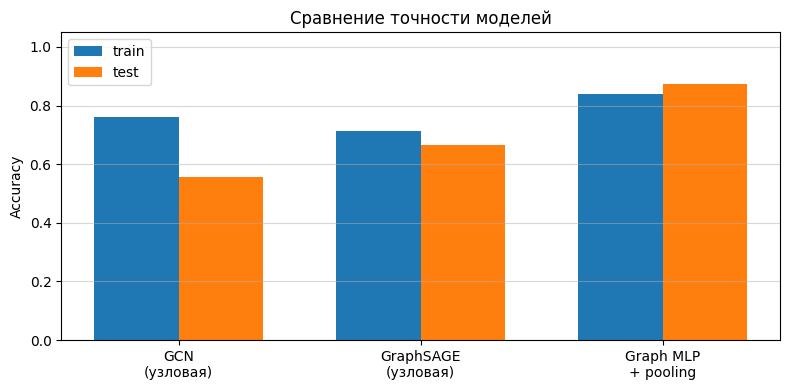

In [10]:
# Задача 9. Сводка метрик

# --- Узловая задача ---
model_gcn.eval()
model_sage.eval()

with torch.no_grad():
    # GCN
    logits_gcn = model_gcn(X2_t, A2_norm_t)
    pred_gcn = logits_gcn.argmax(dim=1)
    train_acc_gcn = (pred_gcn[idx_train_t] == labels2_t[idx_train_t]).float().mean().item()
    test_acc_gcn = (pred_gcn[idx_test_t] == labels2_t[idx_test_t]).float().mean().item()

    # GraphSAGE
    logits_sage = model_sage(X2_t)
    pred_sage = logits_sage.argmax(dim=1)
    train_acc_sage = (pred_sage[idx_train_t] == labels2_t[idx_train_t]).float().mean().item()
    test_acc_sage = (pred_sage[idx_test_t] == labels2_t[idx_test_t]).float().mean().item()

# --- Graph-level задача ---
model_graph.eval()
with torch.no_grad():
    pred_train_graph = model_graph(X_train_t).argmax(dim=1)
    pred_test_graph = model_graph(X_test_t).argmax(dim=1)
    train_acc_graph = (pred_train_graph == y_train_t).float().mean().item()
    test_acc_graph = (pred_test_graph == y_test_t).float().mean().item()

# --- Сводная таблица ---
print("=" * 60)
print(f"{'Модель':<25} {'train_acc':>10} {'test_acc':>10}")
print("=" * 60)
print(f"{'GCN (узловая)':<25} {train_acc_gcn:>10.3f} {test_acc_gcn:>10.3f}")
print(f"{'GraphSAGE (узловая)':<25} {train_acc_sage:>10.3f} {test_acc_sage:>10.3f}")
print(f"{'Graph MLP + pooling':<25} {train_acc_graph:>10.3f} {test_acc_graph:>10.3f}")
print("=" * 60)

# Визуальное сравнение метрик через столбчатую диаграмму
labels_bar = ["GCN\n(узловая)", "GraphSAGE\n(узловая)", "Graph MLP\n+ pooling"]
train_vals = [train_acc_gcn, train_acc_sage, train_acc_graph]
test_vals = [test_acc_gcn, test_acc_sage, test_acc_graph]

x = np.arange(len(labels_bar))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width / 2, train_vals, width, label="train", color="tab:blue")
plt.bar(x + width / 2, test_vals, width, label="test", color="tab:orange")
plt.xticks(x, labels_bar)
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.05)
plt.title("Сравнение точности моделей")
plt.legend()
plt.grid(True, axis="y", alpha=0.5)
plt.tight_layout()
plt.show()


### Выводы по Задаче 9

1. **Полученные результаты**: сводная таблица точностей всех моделей:

   | Модель                | train_acc | test_acc |
   |-----------------------|-----------|----------|
   | GCN (узловая)         | 0.762     | 0.556    |
   | GraphSAGE (узловая)   | 0.714     | 0.667    |
   | Graph MLP + pooling   | 0.839     | 0.875    |

2. **Анализ графиков**: 
   - На столбчатой диаграмме виден явный выигрыш graph-level модели над узловыми: +0.21-0.32 по test_acc.
   - Узловые модели GCN и GraphSAGE сопоставимы по обобщению (0.56 vs 0.67), но GCN переобучается сильнее (train 0.76 vs test 0.56 - gap 0.20), GraphSAGE более стабилен (0.71 vs 0.67 - gap 0.04).
   - Graph-level модель почти не имеет gap между train и test - её сигнал (плотность графа) устойчив к небольшим вариациям выборки.

3. **Интерпретация**: 
   - Разница между узловой и граф-level задачами определяется природой сигнала: в узловой задаче на `planted_partition` сигнал локален и симметричен между классами, поэтому GNN должен учить структурные различия на 30 узлах - мало данных. В граф-level задаче сигнал глобален (плотность), усредняется mean-pool и легко различается.
   - GraphSAGE лучше противостоит overfitting за счёт гибкой агрегации `W_self + W_neigh`, а GCN при малых данных переобучается быстрее из-за жёсткой нормализации.
   - Pooling превращает задачу в классический табличный ML-пайплайн, что радикально упрощает обучение при наличии дискриминирующих статистик.

4. **Практические рекомендации**: 
   - **Узловая классификация на малых графах**: использовать GraphSAGE + регуляризацию (dropout, weight decay) и больше эпох; для лучшего качества добавить structural features.
   - **Inductive задачи** (новые узлы в рантайме): GraphSAGE предпочтителен, так как не требует пересчёта `A_norm`.
   - **Graph-level задачи**: достаточно простого `GNN-шаг -> readout -> MLP` пайплайна, если классы различаются глобальными статистиками. Для более сложных задач (молекулярные свойства, изоморфизм) - GIN или внимательные readout.
   - **Общий вывод**: выбор архитектуры определяется не абсолютной точностью, а типом задачи (node/graph), inductive vs transductive setting, доступным размером обучающей выборки и природой различий между классами.


---

## Интерпретация результатов

В этом задании:

- мы увидели, как граф задается через матрицу смежности и матрицу признаков,
  и как базовые линейные операции реализуют message passing;
- реализовали нормализованный шаг GCN и проверили согласованность размерностей;
- обучили простую GCN-модель для классификации узлов и убедились, что структура графа
  помогает улучшить качество;
- реализовали упрощенный GraphSAGE и сравнили его поведение с GCN по качеству и
  эмбеддингам узлов;
- построили простую graph-level модель на основе одного шага message passing и pooling
  и показали, что она умеет различать классы графов.

Мы также увидели, что выбор архитектуры (GCN vs GraphSAGE) и типа pooling влияет
на разделимость классов и поведение модели на узловых и графовых задачах.


## Выводы

1. Графовые нейронные сети опираются на простые матричные операции (умножение на матрицу смежности
   и линейные преобразования), которые реализуют шаги message passing.
2. GCN использует фиксированную нормализованную матрицу \(\tilde{A}\), что делает слой компактным и
   удобным для трансдуктивных задач.
3. GraphSAGE задает агрегацию соседей явно и хорошо подходит для индуктивных сценариев, где
   граф может меняться или расширяться.
4. Для graph-level задач критично использовать pooling, который агрегирует признаки узлов
   в фиксированный вектор представления графа.
5. Практический выбор архитектуры зависит от постановки: для узловых задач с фиксированным графом
   удобно использовать GCN, для более гибких сценариев и больших графов - варианты GraphSAGE,
   а для задач на графах - комбинации message passing и pooling.